### Import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import glob
from itertools import product
import numpy as np
import graphical_sampling as gs
import pandas as pd
import pickle
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities


In [3]:
os.chdir("/home/bardia/graphical-sampling")

### Reading Data

In [4]:
dfs ={}
path = "/home/bardia/graphical-sampling/simulations/populations"
files = ["aggregated.csv", "regular.csv", "meuse.csv", "swiss.csv"]

def popus(n):
    for f in files:
        full_path = os.path.join(path, f)
        df = pd.read_csv(full_path)
        N = len(df)
        if f in ["aggregated.csv", "regular.csv"]:
            coords = df.iloc[:, :].to_numpy()
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,}
                )
        ##################################
        if f == "meuse.csv":
            coords = df[['x', 'y']].to_numpy()
            probs_up  = inclusion_probabilities(df['copper'].to_numpy(), n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['cadmium'], }
                )
        ###################################
        if f == "swiss.csv":
            coords = df[['x', 'y']].to_numpy()
            AREA = df['AREA'].to_numpy().clip(5,100)
            probs_up  = inclusion_probabilities(AREA, n)
            probs_ep  = np.repeat(n/N, N)
            name = f.replace('.csv', '')
            dfs[f'df_{name}'] = pd.DataFrame(
                {'coord_x':coords[:,0],
                'coord_y':coords[:,1],
                'pik_ep' : probs_ep,
                'pik_up' : probs_up,
                'z'      : df['AREA_A'].to_numpy(), }
                )
        ####################################
    return(dfs)


### Random Population and Parameters

<Axes: title={'center': 'FIP Balanced 20-Means Hard Clustering with Zones'}, xlabel='$X_1$', ylabel='$X_2$'>

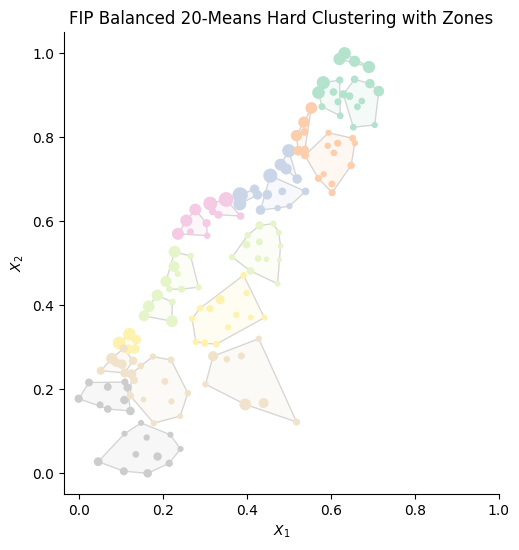

In [5]:
popu = 'df_meuse'
ep_or_up = 'pik_up'
n = 20
num_zones_cluster = [1]
num_zones_sweep = [(1, 1)]
num_splits = [1]

df = popus(n)[popu]
N = len(df)
coords = pd.DataFrame(df[['coord_x', 'coord_y']])
inclusions = df[ep_or_up]
variable = df['z'] if 'z' in df.columns else inclusions

pop = gs.Population(coords, inclusions, n=n, variable=variable)
fbn = gs.clustering.FIPBalancedNMeans(n=n, init_clust_method = 'expanded', split_size = 0.001)
fbn.fit(pop)
fbn.fit_zones(num_zones=(1, 1), mode='sweep_xy')
fbn.plot(mode='hard')

### Pre-Process

In [12]:
initial_designs = []
point_strategies = [
      'lexico_yx', 'angle', 'dist_from_origin',
     'dist_from_centroids', 'max_coord',
    'spiral', None,
    'lexico_xy', 'projection',
]

zone_strategies = [
      'lexico_yx', 'dist_from_origin',
    'spiral', None,
    'lexico_xy', 'projection'
]

zone_modes = [
    'cluster', 'sweep_xy', 'sweep_yx'
]


track = []

num_designs = len(point_strategies) * len(zone_strategies) * len(zone_modes) * len(num_splits)

for point_strategy, zone_strategy, zone_mode, num_split in tqdm(
    product(point_strategies, zone_strategies, zone_modes, num_splits), total=num_designs
):

    if zone_mode == 'cluster':
        list_of_num_zones = num_zones_cluster
    else:
        list_of_num_zones = num_zones_sweep

    for num_zones in list_of_num_zones:

        for _ in range(1):

            fbn = gs.clustering.FIPBalancedNMeans(n)
            fbn.fit(pop)
            # fbn.fit_zones(num_zones=num_zones, mode=zone_mode)

            # try:
            order = gs.Order.from_clusters(
                pop,
                fbn.clusters,
                point_strategy,
                zone_strategy,
                num_split
            )

            design = gs.Design.from_order(pop, order)

            initial_designs.append(design)

            track.append(
                (design.moran[0], design.moran[1], design, zone_strategy, point_strategy, zone_mode, num_zones)
            )
z = sorted(track, key=lambda x: x[0], reverse=False)
z[:1]

  0%|          | 0/162 [00:00<?, ?it/s]

100%|██████████| 162/162 [00:52<00:00,  3.07it/s]


[(-0.3409443351816528,
  0.06340201287637381,
  None,
  'lexico_xy',
  'cluster',
  1)]

In [13]:
initial_moran, initial_std, initial_design, zs, ps, zm, nz = z[0]


In [14]:
srs_var = N**2 * (1-n/N) * np.var(variable)/n

plain_flat = [
    155,
    n,
    5000,
    0,
    np.sum(variable),
    initial_design.nht_variance,
    srs_var / initial_design.nht_variance,
    0,
    initial_design.density_disparity[0],
    initial_design.density_disparity[1],
    initial_design.voronoi[0],
    initial_design.voronoi[1],
    initial_design.moran[0],
    initial_design.moran[1],
    initial_design.local_balance[0],
    initial_design.local_balance[1],
]

print(", ".join(map(str, plain_flat)))


155, 20, 5000, 0, 503.09999999999997, 3358.1447142585153, 3.8435649217268453, 0, 0.04538334735906322, 0.025129906606173303, 0.07610542105731485, 0.029340057951721867, -0.3409443351816528, 0.06340201287637381, 0.18466102717359617, 0.05156707631111345


In [15]:
criteria = gs.criteria.MoranCriteria()
gbfs = gs.search.GreedyBestFirstSearch(initial_designs, criteria)


In [16]:
save_dir_designs = "./simulations/best_design"

initial_design = gbfs.best_design

filename = f"initial_design_{popu}_{n}_{ep_or_up}.pkl"
filepath = os.path.join(save_dir_designs, filename)

if 1 == 1:
    # save your design object
    with open(filepath, "wb") as f:
        pickle.dump(initial_design, f)

gbfs.best_designs = [initial_design]


### GRIZZLY

In [26]:

if 1==1:
    with open(filepath, "rb") as f:
        best_design = pickle.load(f)
        gbfs.initial_designs = [best_design]

In [27]:
gbfs.run(
    max_iterations=2000,        # maximum number of GBFS search iterations (how long the algorithm explores)
    max_open_set_size=1000,     # maximum number of candidate designs stored in the priority queue (search frontier)

    top_k=1,                    # number of best designs tracked during the search (best-so-far solutions)

    num_new_order_nodes=0,     # number of neighbors generated by modifying the ordering of samples
                                # (creates 20 candidate designs by changing sample order)

    num_new_exchange_nodes=100,   # number of neighbors generated using exchange moves
                                # (0 means no swapping of units between samples)

    num_clusters_range=(1,n),             # order changes are applied within up to 2 clusters
                                # (clusters are groups of zones processed together)

    num_zones_range=(1, 1),                # within a cluster, modify only 1 zone at a time

    num_changes_range=(1,3),              # each generated neighbor performs one order modification
                                # (e.g., one swap/reposition in the sequence)

    num_zone_changes=0,         # do not reassign samples between zones (zone structure remains fixed)

    pull_strategy='default',   # rule for selecting samples during exchange operations
                                # (not used here since exchange neighbors are disabled)

    exchange_coef=.75,          # intensity of unit swapping during exchanges
                                # (irrelevant here because num_new_exchange_nodes = 0)

    num_explore=1               # number of designs expanded per iteration
                                # (1 means purely greedy: always expand the current best design)
)


--- Starting Parallel GBFS: Max Iterations=2000, Batch Size=1, Workers=-1 ---
Initial best criteria value: -0.3916
Iter     0/2000 | Best: -0.3916 | Open:     1 | Closed:     0
0: -0.3916257,  exchange,  DSize:157,  var:2140.27, Entp:4.65
2: -0.3916258,  exchange,  DSize:161,  var:2140.27, Entp:4.65
3: -0.3916258,  exchange,  DSize:160,  var:2140.27, Entp:4.65
4: -0.3916270,  exchange,  DSize:160,  var:2140.67, Entp:4.66
5: -0.3916343,  exchange,  DSize:162,  var:2140.70, Entp:4.66
6: -0.3916350,  exchange,  DSize:164,  var:2140.77, Entp:4.67
7: -0.3916350,  exchange,  DSize:166,  var:2140.77, Entp:4.67
7: -0.3919590,  exchange,  DSize:166,  var:2141.20, Entp:4.69
9: -0.3919591,  exchange,  DSize:170,  var:2141.70, Entp:4.71
10: -0.3919591,  exchange,  DSize:170,  var:2141.70, Entp:4.71
10: -0.3919591,  exchange,  DSize:170,  var:2141.70, Entp:4.71
12: -0.3919609,  exchange,  DSize:172,  var:2141.38, Entp:4.71
13: -0.3919609,  exchange,  DSize:171,  var:2141.38, Entp:4.71
14: -0.391962

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f1c7f05e5c0>>
Traceback (most recent call last):
  File "/home/bardia/graphical-sampling/.venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

In [28]:

filename = f"best_design_{popu}_{n}_{ep_or_up}.pkl"
filepath = os.path.join(save_dir_designs, filename)

# save your design object
with open(filepath, "wb") as f:
    pickle.dump(gbfs.best_design, f)
gbfs.initial_designs = [gbfs.best_design]

In [29]:
srs_var = N**2 * (1-n/N) * np.var(variable)/n
plain_flat = [
    155,
    n,
    5000,
    0,
    np.sum(variable),
    float(gbfs.best_design.nht_variance),
    float(srs_var / gbfs.best_design.nht_variance),
    0,
    *map(float, gbfs.best_design.density_disparity),
    *map(float, gbfs.best_design.voronoi),
    *map(float, gbfs.best_design.moran),
    *map(float, gbfs.best_design.local_balance),
]
arr = np.array(plain_flat, dtype=float)
simple = [float(x) for x in arr]
# Example: flatten all tuples in the list
flat = []
for x in simple:
    if isinstance(x, tuple):
        flat.extend(x)
    else:
        flat.append(x)

print(', '.join(str(x) for x in flat))




155.0, 20.0, 5000.0, 0.0, 503.09999999999997, 2187.4235398111823, 5.900662121849799, 0.0, 0.040832679473039674, 0.04500875434629094, 0.08653188129930753, 0.021185410773838703, -0.39293055652442893, 0.05752462492851097, 0.19332815506831733, 0.049667440933842434


# Store

In [ ]:
raise SystemExit("Stopping Run All: Archived cells below.")

SystemExit: Stopping Run All: Archived cells below.

/home/bardia/graphical-sampling/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
dir(gbfs.best_design)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_all_samples_and_probs',
 '_build',
 '_density_expected_and_variance',
 '_entropy',
 '_expected_and_variance',
 '_fip',
 '_heaps',
 '_indicator_matrix',
 '_local_balance_expected_and_variance',
 '_maximum_entropy',
 '_moran_expected_and_variance',
 '_nht_variance',
 '_num_partitions',
 '_order',
 '_pop',
 '_pull',
 '_push',
 '_reset_stats',
 '_rng',
 '_sip',
 '_switch',
 '_voronoi_expected_and_variance',
 'all_samples_and_probs',
 'copy',
 'density_disparity',
 'entropy',
 'events',
 'exchange',
 'fip',
 'from_order',
 'indicator_matrix',
 'local_balance',
 'maximum_entropy',
 '

In [ ]:

gbfs.best_design.entropy
len(gbfs.best_design.all_samples_and_probs[1])

gbfs.best_design.merge_identical()


print(len(gbfs.best_design.all_samples_and_probs[0]))

696


In [ ]:
gbfs.best_design